# Question:

#### *How does my SAT score compare to the average SAT scores of post-secondary institutions that have female graduates earning at least $100,000 10 years after graduation? How does it compare to the average SAT scores of post-secondary institutions with male graduates earning the same salary in the same time after graduation?*

## Type of study
##### This is a census study because I am analyzing the whole population of post-secondary institutions, which is presented in the dataset collected by the federal government. Since the government is collecting this data, it is very likely that almost every single post-secondary study is presented in the dataset.

# Analysis

In [16]:
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt

In [3]:
college = pd.read_csv("cleaned_college.csv")

In [4]:
my_sat = 1490

<Axes: xlabel='median_earnings_10yrs_women', ylabel='Count'>

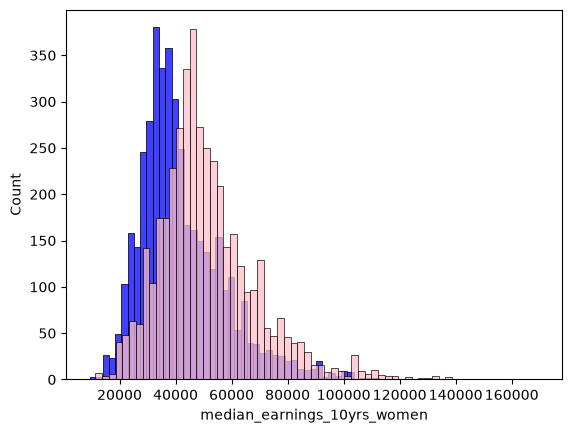

In [10]:
sb.histplot(data=college, x="median_earnings_10yrs_women", color="blue")
sb.histplot(data=college, x="median_earnings_10yrs_men", color="pink")
#the male earnings are very clearly higher than the women

In [32]:
#first, filter the post-secondary institutions with women gradutates earning at least 100k 10 years post-graduation
women = college[college["median_earnings_10yrs_women"] >= 100000]
women.info()
women.to_excel("women.xlsx")

<class 'pandas.DataFrame'>
Index: 30 entries, 185 to 5846
Columns: 124 entries, school_id to main_degree
dtypes: float64(110), int64(8), str(6)
memory usage: 31.5 KB


In [31]:
#filter the men with the same criteria
men = college[college["median_earnings_10yrs_men"] >= 100000]
men.info()
men.to_excel("men.xlsx")

<class 'pandas.DataFrame'>
Index: 91 entries, 102 to 5915
Columns: 124 entries, school_id to main_degree
dtypes: float64(110), int64(8), str(6)
memory usage: 95.2 KB


In [11]:
#just another stat to possibly explain the 3x men than women (obviously other than the reason that men get paid more for being men)
wom = college[college["pct_women"] >= .4]
wom.info() #this is very interesting, but also a little sad :(

<class 'pandas.DataFrame'>
Index: 4722 entries, 0 to 5733
Columns: 124 entries, school_id to main_degree
dtypes: float64(110), int64(8), str(6)
memory usage: 4.8 MB


In [12]:
#let's calculate z-scores! Looking at women first, let's find the mean of the sat scores:
avg_wom_sat = women["sat_average"].mean()
print(avg_wom_sat)

#find standard deviation
std_wom_sat = women["sat_average"].std()
print(std_wom_sat) #whoa that's a high discreptancy esp among high salaries!

#find the z-score for my sat score
wom_zsc = (my_sat - avg_wom_sat) / std_wom_sat
print(wom_zsc)

1425.5
132.361829264157
0.4873006089336839


In [15]:
#let's calculate z-scores for men now. find the mean of the sat scores
avg_men_sat = men["sat_average"].mean()
print(avg_men_sat) #this is higher than women...huh

#find standard deviation
std_men_sat = men["sat_average"].std()
print(std_men_sat) #the discreptancy is much lower for the men...maybe because there are more men than women to look at?

#find the z-score for my sat score
men_zsc = (my_sat - avg_men_sat) / std_men_sat
print(men_zsc)

1482.5
95.49380905361126
0.07853912284292083


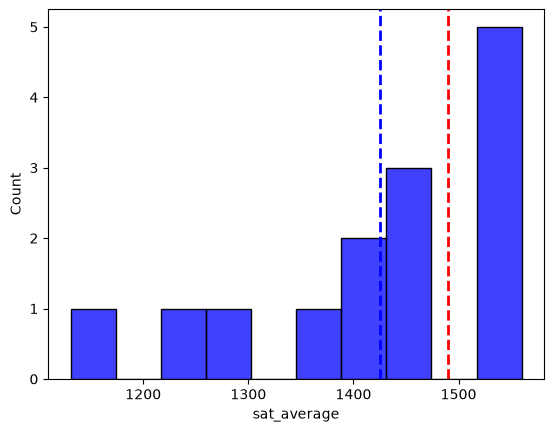

In [27]:
#let's create graphs of sat scores to visualize this, with a marker for my score:
#women:
sb.histplot(data=women, x="sat_average", color="blue", bins=10)
plt.axvline(x=my_sat, color="red", linestyle="--", linewidth=2, label="Target: My Score")
plt.axvline(x=avg_wom_sat, color="blue", linestyle="--", linewidth=2, label="Target: My Score")

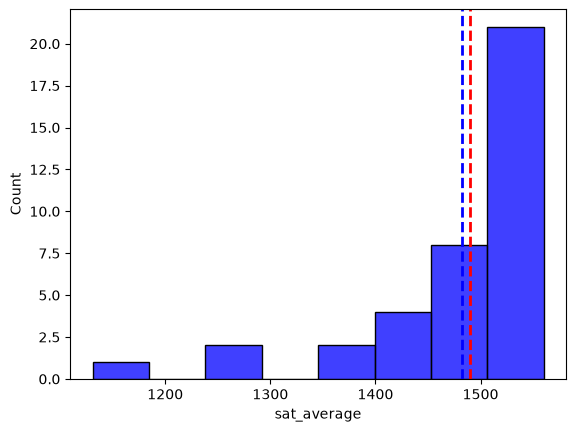

In [29]:
#men:
sb.histplot(data=men, x="sat_average", color="blue")
plt.axvline(x=my_sat, color="red", linestyle="--", linewidth=2, label="Target: My Score")
plt.axvline(x=avg_men_sat, color="blue", linestyle="--", linewidth=2, label="Target: My Score")

desmos calculations:

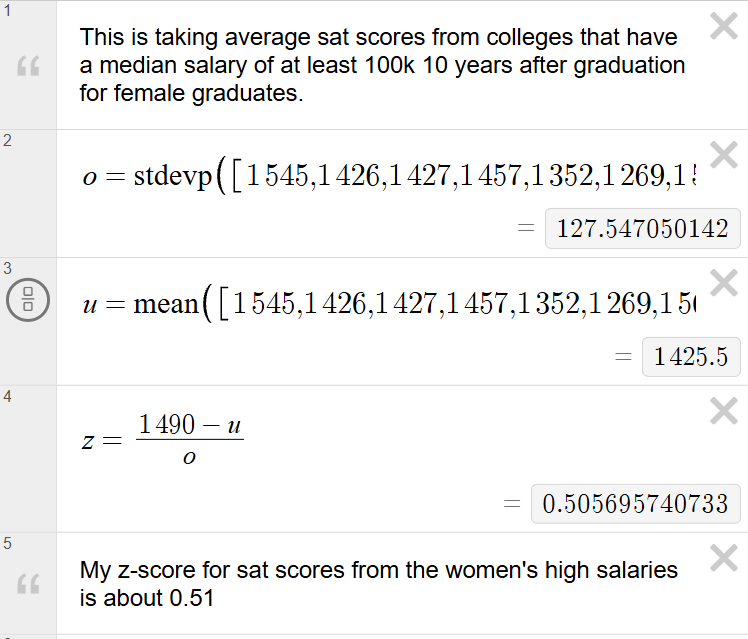
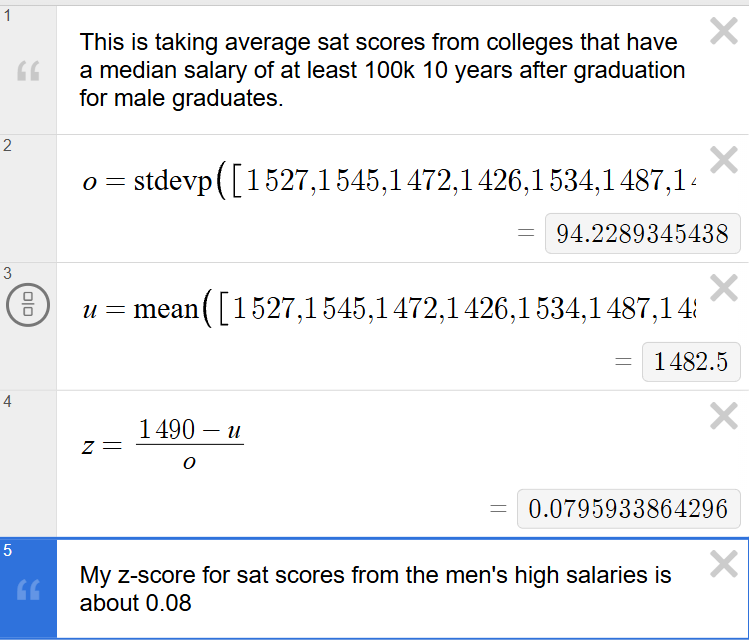

# Conclusion

##### - My SAT score was significantly higher than the average SAT scores of post-secondary institutions that have female graduates earning at least $100,000 10 years after graduation, while it was only a little bit higher than the average SAT scores of men in the same category. 
##### - This is because my z-score for average high-paying female SAT scores was about 0.5, which was much higher than my z-score for average high-paying male SAT scores, which was only about 0.08. The higher z-score means that I was farther from the mean in the female section than in the male section, in which I had a smaller z-score.
##### - This can also be seen in the graphs. In both histograms for men and women, the mean is depicted by the blue vertical line, and my SAT score is depicted by the red vertical line. We can see that there is a bigger gap between my SAT score and the mean in the women's SAT graph than in the men's graph, as the ranges (the highest and lowest scores displayed) are similar. The score distributions are also somewhat similar, as the frequency of the number of people who got the score increase as the SAT score increased. Therefore, it is resonable to say I am significantly better than the mean in women's average SAT scores than men just looking at the difference in the gaps between my score and the mean.